In [1]:
# Gameplan sequence

#Pre-game actions: Iteratiuve London mulligan (with card type requirements)

# Turn 0: 
# Draw 7 (Cards in hand = 7; Total cards seen = 7)
# Do mulligan once. If not fulfilling requirements, do it again. Regardless of the second result, go ahead.

# Turn 1
# Draw 1 (Cards in hand = 8; Total cards seen = 8)
# Play a land (Cards in hand = 7; Total cards seen = 8)
# If available, play a 1CMC draw spell. If so, add 1 to the number of seen cards onwards.

# Turn 2
# Draw 1 (Cards in hand = 8; Total cards seen = 9)
# Play a land (Cards in hand = 7; Total cards seen = 9)
# Play a ramp piece (Cards in hand = 6; Total cards seen = 9)

#Turn 3:
# Draw 1 (Cards in hand = 7; Total cards seen = 10)
# Play A&N (no effect in hand)

#Turn 4:
# Draw 1 (Cards in hand = 8; Total cards seen = 11)
# Play Bomb (Cards in hand = 7; Total cards seen = 11)

In [2]:
import numpy as np
from lib.simulation import simulate_games, CARD_TYPE_MAP
from lib.analysis import print_simulation_report, LRBD_grid_search, analyze_sensitivity, analyze_single_variable
%matplotlib widget
N = 99 #always 99 cards in deck

In [3]:
# --- Numba compilation of simulation function --- #
L = 0      # lands
R = 0      # ramp
B = 0      # bombs
D = 0      # draw 
t_land = 0  # minimum lands to keep hand
t_ramp = 0  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
t_draw = 0  # minimum draw to keep hand
N_mulligans = 5
user_priority = ("O", "B", "D", "R", "L")


# --- Build the deck template ---
base_deck = np.concatenate([
    np.ones(L, dtype=np.uint8),             # land card type = 1
    np.full(R, 2, dtype=np.uint8),          # ramp card type = 2
    np.full(B, 3, dtype=np.uint8),          # bomb card type = 3
    np.full(D, 4, dtype=np.uint8),          # draw card type = 4
    np.zeros(N - L - R - B - D, dtype=np.uint8) # filler / other cards = 0
])

# --- Game plan (per turn list of card types to play) ---
gameplan = [
    np.array([1, 4], dtype=np.uint8),   # turn 1: play land + optional draw
    np.array([1, 2], dtype=np.uint8),   # turn 2: play land and ramp
    np.array([1], dtype=np.uint8),      # turn 3: play land
    np.array([1, 3], dtype=np.uint8)    # turn 4: play land and bomb
]

# --- Run simulation once (for Numba compilation) ---
numeric_priority = tuple(CARD_TYPE_MAP[c] for c in user_priority)
result, fails, mulligans = simulate_games(1, base_deck, t_land, t_ramp, t_bomb, t_draw, gameplan, 
                                          N_mulligans, numeric_priority)
print("Compilation OK")

Compilation OK


In [7]:
# --- Run full simulation with user input parameters ---
L = 36 # number of lands
R = 15 # number of ramp pieces 
B = 17 # number of bombs
D = 5 # number of cmc=1 draw spells
t_land = 2  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
t_draw = 0
N_sim = 1_000_000  # number of simulations
N_mulligans = 5
user_priority = ("O", "B", "D", "R", "L")


# --- Build the deck template ---
base_deck = np.concatenate([
    np.ones(L, dtype=np.uint8),             # land card type = 1
    np.full(R, 2, dtype=np.uint8),          # ramp card type = 2
    np.full(B, 3, dtype=np.uint8),          # bomb card type = 3
    np.full(D, 4, dtype=np.uint8),          # draw card type = 4
    np.zeros(N - L - R - B - D, dtype=np.uint8) # filler / other cards = 0
])

numeric_priority = tuple(CARD_TYPE_MAP[c] for c in user_priority)
result, fail_summary, mulligan_stats = simulate_games(N_sim, base_deck, t_land, t_ramp, t_bomb, t_draw, gameplan,
                                                 N_mulligans, numeric_priority)
print_simulation_report(result, fail_summary, mulligan_stats, N_sim, N_mulligans)


✅ Success rate: 60.23%
❌ Failure rate: 39.77%

🎲 Mulligan usage breakdown:
0 mulligan(s): 528374 games → 52.84%
1 mulligan(s): 248707 games → 24.87%
2 mulligan(s): 118365 games → 11.84%
3 mulligan(s): 55423 games → 5.54%
4 mulligan(s): 25890 games → 2.59%
5 mulligan(s): 23241 games → 2.32%

🔎 Failure breakdown by operation (as % of ALL games):
 Turn 1 - Play Land:  0.053%
 Turn 2 - Play Land:  0.140%
 Turn 2 - Play Ramp:  0.460%
 Turn 3 - Play Land:  9.214%
 Turn 4 - Play Land: 16.742%
 Turn 4 - Play Bomb: 13.158%

📊 Conditional breakdown (as % of FAILED games):
 Turn 1 - Play Land:   0.13%
 Turn 2 - Play Land:   0.35%
 Turn 2 - Play Ramp:   1.16%
 Turn 3 - Play Land:  23.17%
 Turn 4 - Play Land:  42.10%
 Turn 4 - Play Bomb:  33.09%


In [6]:
# Optimization search
N_sim = 10_000  # number of simulations on each combination

Lmin = 33
Lmax = 38

Rmin = 12
Rmax = 15

Bmin = 12
Bmax = 15

Dmin = 0
Dmax = 10

#Mulligan targets
t_land = 2  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
t_draw = 0
N_mulligans = 5
user_priority = ("O", "B", "D", "R", "L")

#Run search
data, best_config, best_rate, best_fail_summary = LRBD_grid_search(Lmin, Lmax, Rmin, Rmax, Bmin, Bmax, Dmin, Dmax,
                                                                   N, t_land, t_ramp, t_bomb, t_draw, N_sim,
                                                                   gameplan, N_mulligans, user_priority)

dic = analyze_sensitivity(data)


🚀 Starting optimization over 1056 combinations...

Checked 500/1056 configs (Best: L=35, R=14, B=15, D=9 → 56.48%) Elapsed: 2.1s
Checked 1000/1056 configs (Best: L=38, R=13, B=15, D=7 → 61.19%) Elapsed: 4.0s
Checked 1056/1056 configs (Best: L=38, R=15, B=15, D=10 → 62.87%) Elapsed: 4.2s

✅ Optimization complete in 4.2s.
🔹 Best configuration: Lands=38, Ramp=15, Bombs=15, Draw=10
🔹 Success rate: 62.87%

🔍 Sensitivity Summary (ΔSuccessRate per +1 card):
  Lands (L): +1.926% per +1
  Ramp  (R): +0.672% per +1
  Bombs (B): +2.000% per +1
  Draws (D): +0.465% per +1
🏆 Strongest influence: Bombs (+2.000% per card)



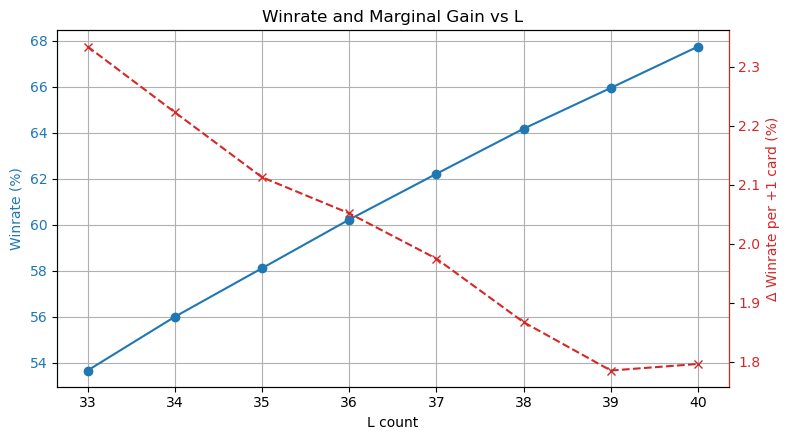

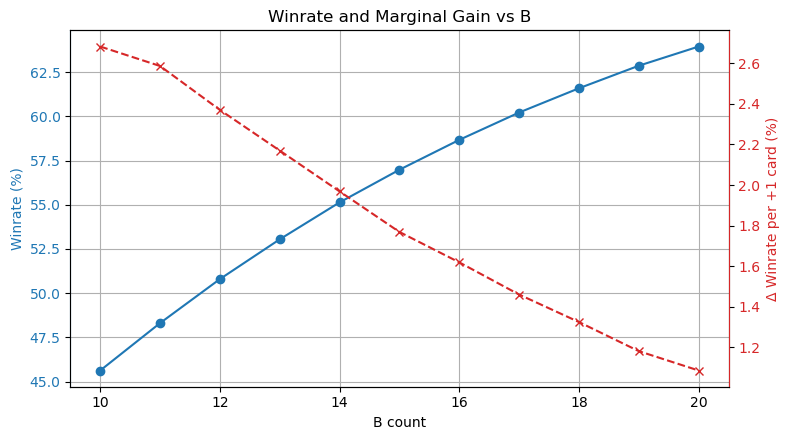

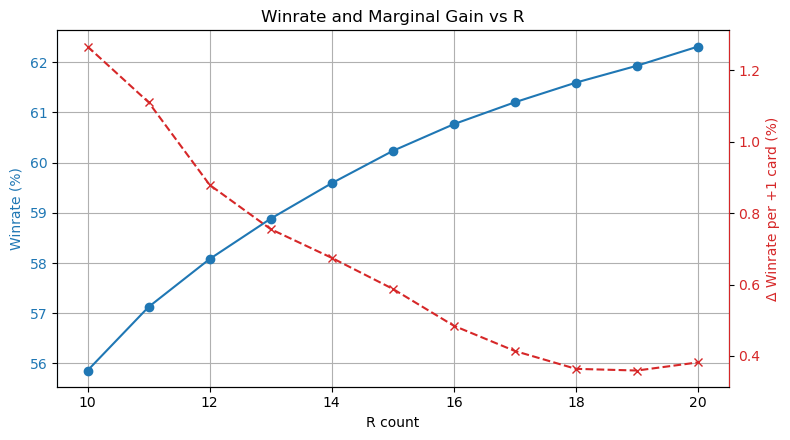

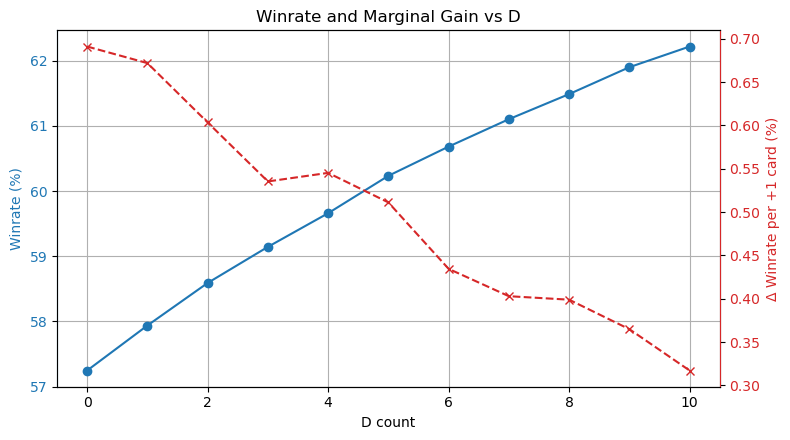

In [8]:
# Evaluate variation along each axis

fixed_config = {'L': 36, 'R': 15,'B': 17,'D': 5}
N_sim = 5_000_000
t_land = 2  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
t_draw = 0
N_mulligans = 5
priority = ("O", "B", "D", "R", "L")

values_L, winrates_L, deriv_L = analyze_single_variable('L', 33, 40,
                                           fixed_config, N,
                                           t_land, t_ramp, t_bomb, t_draw,
                                           N_sim, gameplan,
                                           N_mulligans, priority)

values_B, winrates_B, deriv_B = analyze_single_variable('B', 10, 20,
                                           fixed_config, N,
                                           t_land, t_ramp, t_bomb, t_draw,
                                           N_sim, gameplan,
                                           N_mulligans, priority)

values_R, winrates_R, deriv_R = analyze_single_variable('R', 10, 20,
                                           fixed_config, N,
                                           t_land, t_ramp, t_bomb, t_draw,
                                           N_sim, gameplan,
                                           N_mulligans, priority)

values_D, winrates_D, deriv_D = analyze_single_variable('D', 0, 10,
                                           fixed_config, N,
                                           t_land, t_ramp, t_bomb, t_draw,
                                           N_sim, gameplan,
                                           N_mulligans, priority)